# Step 5 — Porównanie domen: Filmweb, Sport, Technologia

Czy wyniki ekstrakcji grafów wiedzy generalizują się na różne domeny tematyczne?  
4 modele × 3 domeny (filmweb + sport + technologia) × 8 artykułów każda = **96 obserwacji**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display, HTML

COLS = ["position", "id", "title", "model", "prompt",
        "precision", "recall", "hall", "miss",
        "t_precision", "t_recall", "t_hall", "t_miss", "connectivity"]

df = pd.read_csv("step_5_more_domains.csv", header=None, names=COLS)

def short_label(m):
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

df["model_short"] = df["model"].apply(short_label)
df["title_short"] = df["title"].str.replace("_", " ").str[:38]
df["domain"] = df["prompt"].apply(
    lambda p: "Sport" if p.startswith("sport")
    else ("Tech" if p.startswith("tech") else "Filmweb")
)

df["t_f1"] = 2 * df["t_precision"] * df["t_recall"] / (df["t_precision"] + df["t_recall"])
df["f1"]   = 2 * df["precision"]   * df["recall"]   / (df["precision"]   + df["recall"])

TOP4 = ["gemma-4-26b-a4b-it", "gemma-4-31b-it", "mistral-small-3.2-24b-instruct", "qwen3-32b"]
MODEL_COLORS = {
    "gemma-4-26b-a4b-it":             "#e41a1c",
    "gemma-4-31b-it":                 "#377eb8",
    "mistral-small-3.2-24b-instruct": "#4daf4a",
    "qwen3-32b":                      "#984ea3",
}
DOMAINS = ["Filmweb", "Sport", "Tech"]
DOMAIN_COLORS = {"Filmweb": "#4878d0", "Sport": "#ee854a", "Tech": "#55a868"}
DOMAIN_ROW_COLORS = {"Filmweb": "#eef3fb", "Sport": "#fff8f2", "Tech": "#f2fbf3"}

def color_domain(row):
    key = row.get("Domena", row.get("domain", ""))
    return [f"background-color: {DOMAIN_ROW_COLORS.get(key, '')}" for _ in row]

NUMERIC = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1", "connectivity"]

print(f"{len(df)} wierszy | {df['model_short'].nunique()} modele | {df['domain'].value_counts().to_dict()}")
display(
    df.groupby("domain")[NUMERIC].mean()
    .loc[DOMAINS].round(3)
    .style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
    .format("{:.1%}")
)

96 wierszy | 4 modele | {'Tech': 32, 'Sport': 32, 'Filmweb': 32}


,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
domain,,,,,,,
Filmweb,93.8%,71.1%,80.0%,83.5%,75.6%,76.7%,82.0%
Sport,75.8%,65.0%,68.9%,77.6%,80.6%,77.2%,88.0%
Tech,90.8%,65.1%,75.5%,74.8%,60.1%,65.6%,90.7%


## Średnie per model × domena

In [2]:
for sort_col, label in [("t_f1", "T-F1"), ("t_precision", "T-Precision"), ("precision", "Precision")]:
    display(HTML(f"<h4>Ranking wg {label}</h4>"))
    summary = (
        df.groupby(["model_short", "domain"])[NUMERIC]
        .mean().round(3).reset_index()
    )
    summary["domain"] = pd.Categorical(summary["domain"], categories=DOMAINS, ordered=True)
    summary = summary.sort_values(["model_short", "domain"])
    summary = summary.rename(columns={"model_short": "Model", "domain": "Domena"})
    display(
        summary.style
        .apply(color_domain, axis=1)
        .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in NUMERIC})
        .hide(axis="index")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
    )

Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-26b-a4b-it,Tech,91.6%,67.3%,77.4%,77.8%,66.5%,70.9%,84.7%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
gemma-4-31b-it,Tech,93.6%,65.6%,76.5%,84.2%,60.5%,69.3%,93.2%
mistral-small-3.2-24b-instruct,Filmweb,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
mistral-small-3.2-24b-instruct,Sport,67.8%,69.6%,68.5%,63.9%,83.9%,70.8%,93.8%
mistral-small-3.2-24b-instruct,Tech,88.9%,65.6%,75.2%,66.0%,60.2%,62.0%,92.0%
qwen3-32b,Filmweb,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%


Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-26b-a4b-it,Tech,91.6%,67.3%,77.4%,77.8%,66.5%,70.9%,84.7%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
gemma-4-31b-it,Tech,93.6%,65.6%,76.5%,84.2%,60.5%,69.3%,93.2%
mistral-small-3.2-24b-instruct,Filmweb,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
mistral-small-3.2-24b-instruct,Sport,67.8%,69.6%,68.5%,63.9%,83.9%,70.8%,93.8%
mistral-small-3.2-24b-instruct,Tech,88.9%,65.6%,75.2%,66.0%,60.2%,62.0%,92.0%
qwen3-32b,Filmweb,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%


Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-26b-a4b-it,Tech,91.6%,67.3%,77.4%,77.8%,66.5%,70.9%,84.7%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
gemma-4-31b-it,Tech,93.6%,65.6%,76.5%,84.2%,60.5%,69.3%,93.2%
mistral-small-3.2-24b-instruct,Filmweb,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
mistral-small-3.2-24b-instruct,Sport,67.8%,69.6%,68.5%,63.9%,83.9%,70.8%,93.8%
mistral-small-3.2-24b-instruct,Tech,88.9%,65.6%,75.2%,66.0%,60.2%,62.0%,92.0%
qwen3-32b,Filmweb,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%


## Wykres porównawczy: 3 domeny × 4 metryki

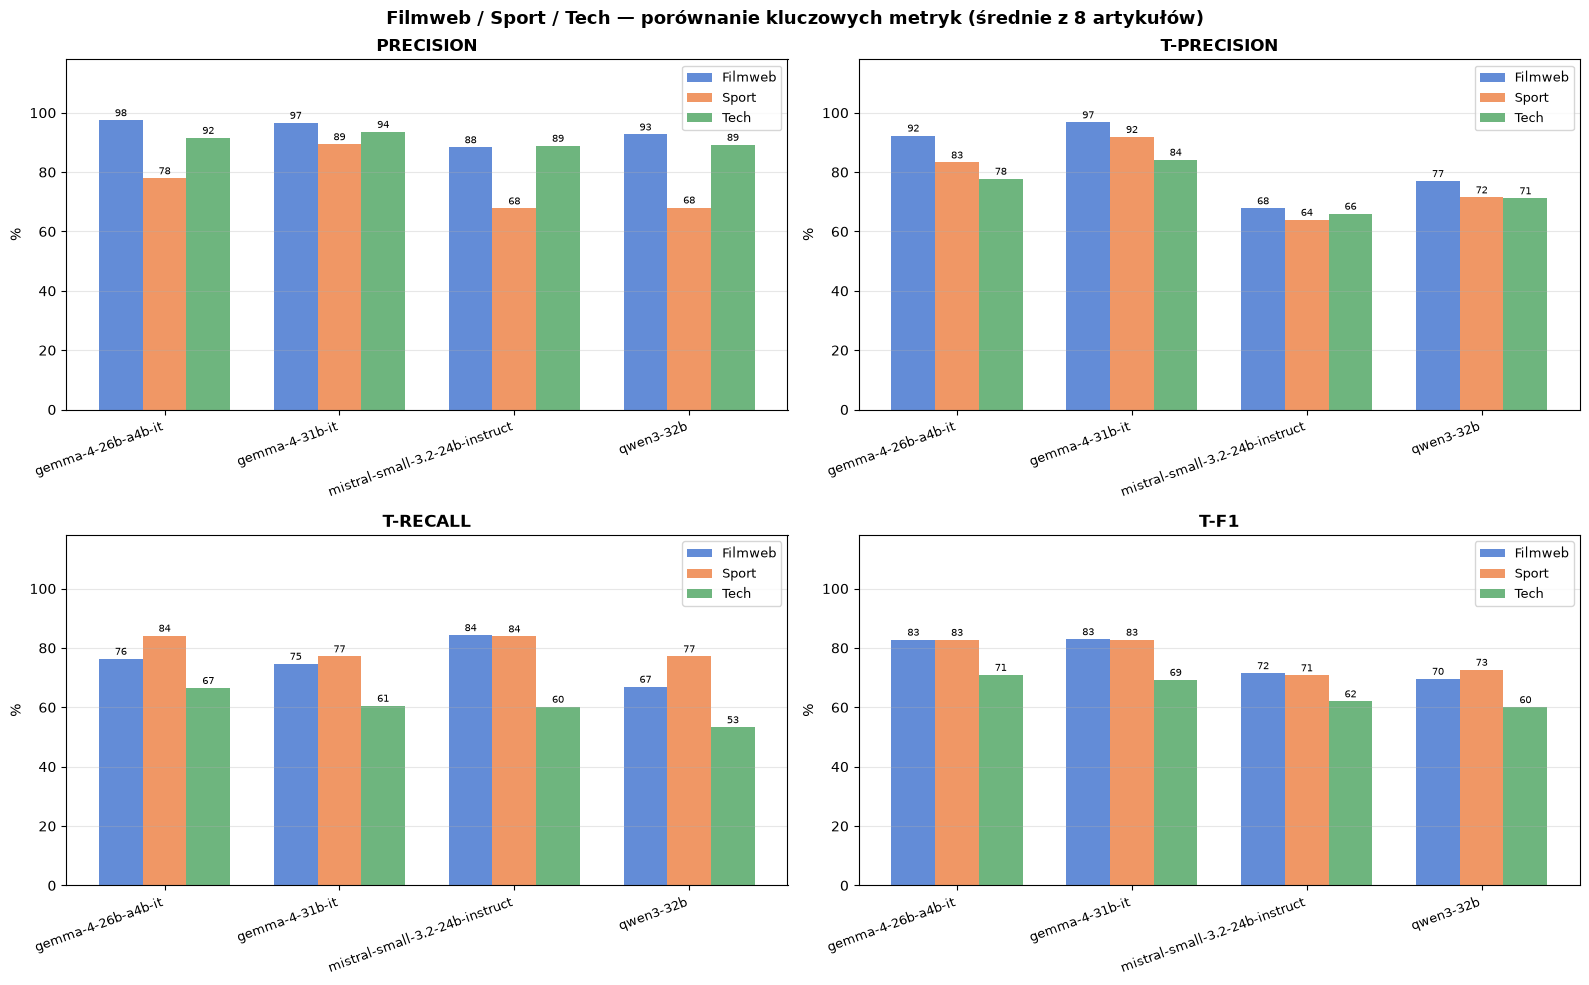

In [3]:
agg = df.groupby(["model_short", "domain"])[NUMERIC].mean().reset_index()
model_labels = [short_label(m) for m in TOP4]
x = np.arange(len(TOP4))
w = 0.25

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, ["precision", "t_precision", "t_recall", "t_f1"]):
    for i, domain in enumerate(DOMAINS):
        vals = []
        for m in TOP4:
            ms = short_label(m)
            row = agg[(agg["model_short"] == ms) & (agg["domain"] == domain)]
            vals.append(row[metric].values[0] * 100 if len(row) else 0)
        offset = (i - 1) * w
        bars = ax.bar(x + offset, vals, w, label=domain, color=DOMAIN_COLORS[domain], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 118)
    ax.set_ylabel("%")
    ax.set_title(metric.replace("_", "-").upper(), fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Filmweb / Sport / Tech — porównanie kluczowych metryk (średnie z 8 artykułów)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Wykres do pracy — Precision, Recall, T-Precision, T-Recall per domena, 4 modele (odpowiednik Tabeli 4.11)

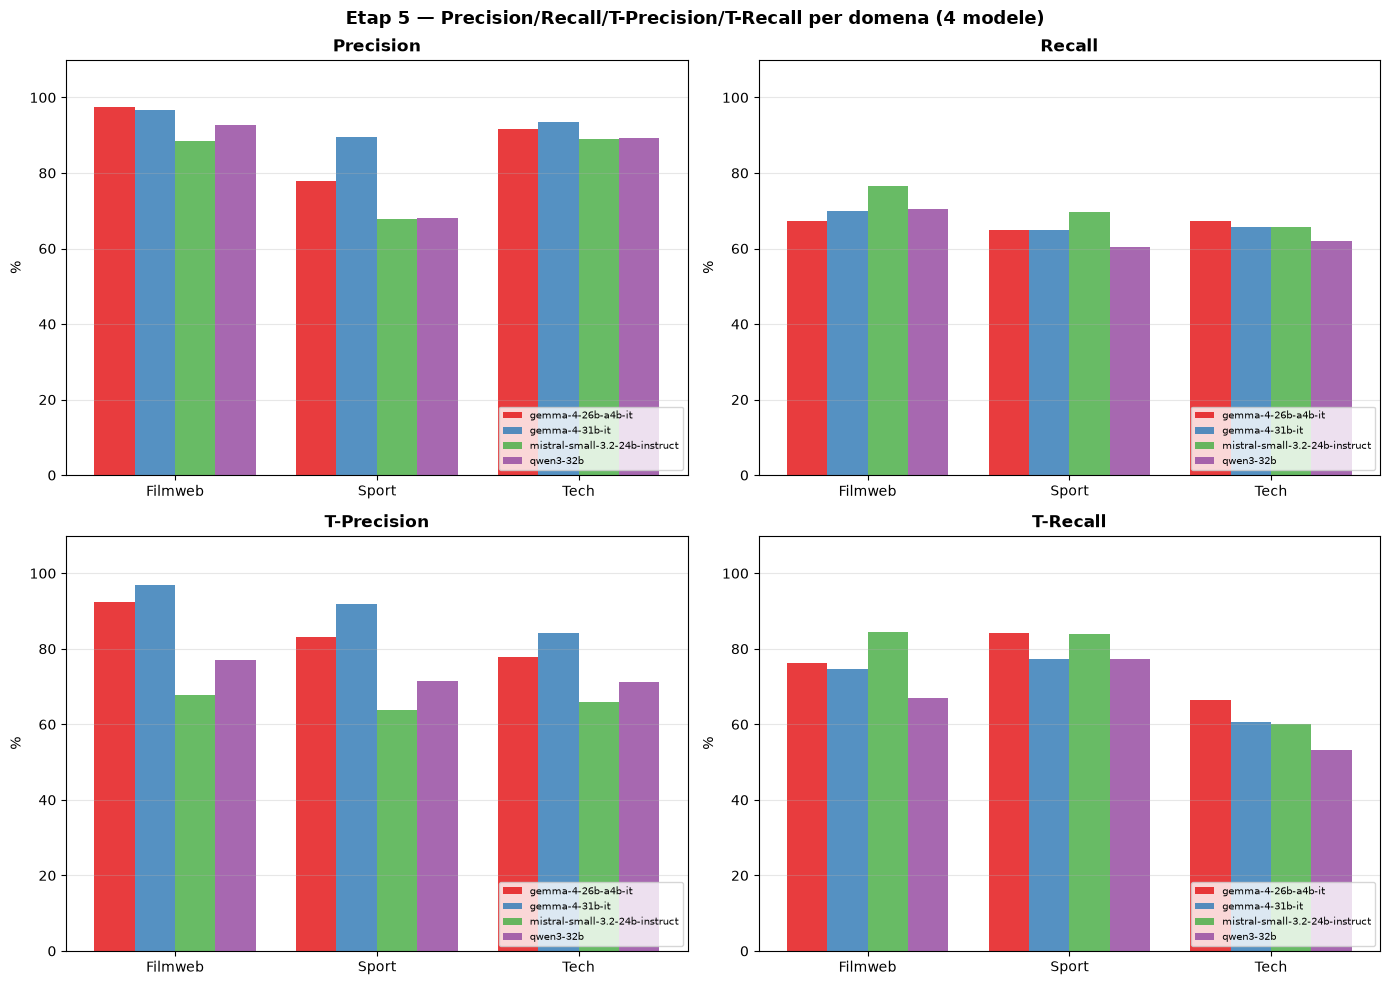

In [4]:
agg2 = df.groupby(["model_short", "domain"])[NUMERIC].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(len(DOMAINS))
w = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

metrics5 = ["precision", "recall", "t_precision", "t_recall"]
mlabels5 = ["Precision", "Recall", "T-Precision", "T-Recall"]

for ax, metric, mlabel in zip(axes, metrics5, mlabels5):
    for model, offset in zip(TOP4, offsets):
        ms = short_label(model)
        vals = []
        for dom in DOMAINS:
            row = agg2[(agg2["model_short"] == ms) & (agg2["domain"] == dom)]
            vals.append(row[metric].values[0] * 100 if len(row) else np.nan)
        ax.bar(x + offset * w, vals, w, label=ms, color=MODEL_COLORS[model], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(DOMAINS, fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_ylabel("%")
    ax.set_title(mlabel, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Etap 5 \u2014 Precision/Recall/T-Precision/T-Recall per domena (4 modele)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


## Tabela delta: zmiana Filmweb → Sport oraz Filmweb → Tech

In [5]:
agg_pivot = df.groupby(["model_short", "domain"])[NUMERIC].mean().unstack("domain").round(3)
delta_cols = ["precision", "t_precision", "t_recall", "t_f1"]

for target, label in [("Sport", "Sport − Filmweb"), ("Tech", "Tech − Filmweb")]:
    delta = pd.DataFrame(index=agg_pivot.index)
    for c in delta_cols:
        delta[c] = agg_pivot[(c, target)] - agg_pivot[(c, "Filmweb")]
    delta = delta.round(3)
    delta.index.name = "Model"
    delta.columns = [f"Δ{c.replace('_','-').upper()}" for c in delta_cols]
    display(HTML(f"<h4>Delta {label} (+ = nowa domena lepsza)</h4>"))
    display(
        delta.style
        .background_gradient(cmap="RdYlGn", vmin=-0.35, vmax=0.35)
        .format("{:+.1%}")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
    )

,ΔPRECISION,ΔT-PRECISION,ΔT-RECALL,ΔT-F1
Model,,,,
gemma-4-26b-a4b-it,-19.6%,-9.1%,+7.7%,-0.1%
gemma-4-31b-it,-7.2%,-4.9%,+2.5%,-0.2%
mistral-small-3.2-24b-instruct,-20.6%,-3.9%,-0.4%,-0.7%
qwen3-32b,-24.6%,-5.5%,+10.3%,+3.0%


,ΔPRECISION,ΔT-PRECISION,ΔT-RECALL,ΔT-F1
Model,,,,
gemma-4-26b-a4b-it,-5.9%,-14.5%,-9.9%,-11.9%
gemma-4-31b-it,-3.0%,-12.6%,-14.2%,-13.7%
mistral-small-3.2-24b-instruct,+0.5%,-1.8%,-24.1%,-9.5%
qwen3-32b,-3.5%,-5.8%,-13.6%,-9.5%


## Trajektoria T-F1 przez domeny (Filmweb → Sport → Tech)

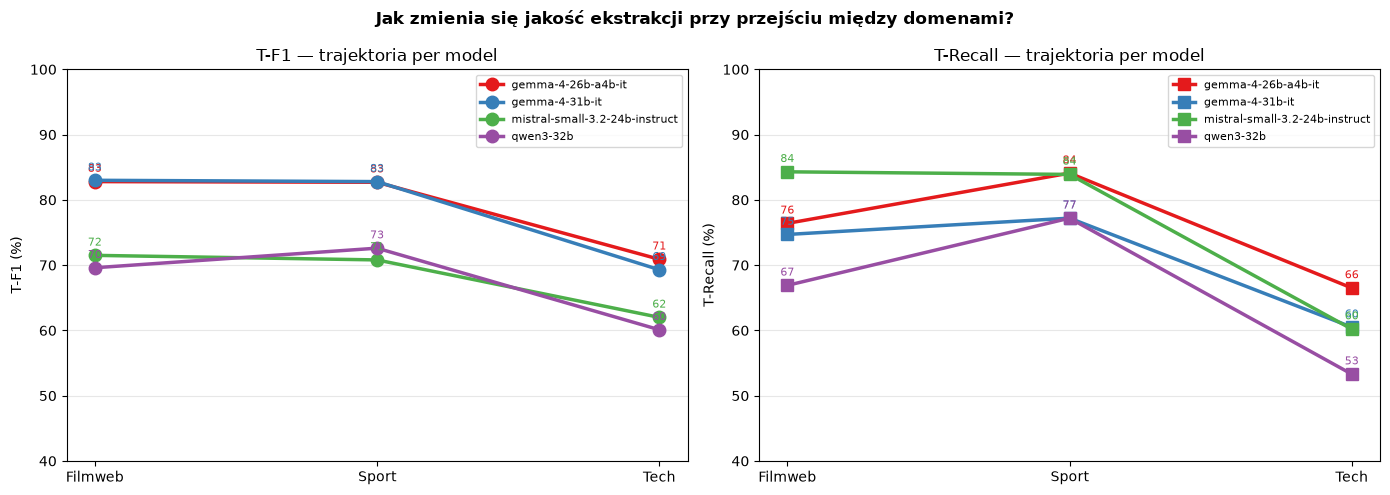

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: T-F1 trajectory per model
ax = axes[0]
for m in TOP4:
    ms = short_label(m)
    vals = [agg_pivot[("t_f1", d)][ms] * 100 for d in DOMAINS]
    ax.plot(DOMAINS, vals, marker="o", label=ms, color=MODEL_COLORS[m], linewidth=2.5, markersize=9)
    for d, v in zip(DOMAINS, vals):
        ax.annotate(f"{v:.0f}", (d, v), textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=8, color=MODEL_COLORS[m])
ax.set_ylim(40, 100)
ax.set_ylabel("T-F1 (%)")
ax.set_title("T-F1 — trajektoria per model")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Right: T-Recall trajectory (where tech typically drops more)
ax = axes[1]
for m in TOP4:
    ms = short_label(m)
    vals = [agg_pivot[("t_recall", d)][ms] * 100 for d in DOMAINS]
    ax.plot(DOMAINS, vals, marker="s", label=ms, color=MODEL_COLORS[m], linewidth=2.5, markersize=9)
    for d, v in zip(DOMAINS, vals):
        ax.annotate(f"{v:.0f}", (d, v), textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=8, color=MODEL_COLORS[m])
ax.set_ylim(40, 100)
ax.set_ylabel("T-Recall (%)")
ax.set_title("T-Recall — trajektoria per model")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Jak zmienia się jakość ekstrakcji przy przejściu między domenami?", fontweight="bold")
fig.tight_layout()
plt.show()

## Heatmapy T-F1 i Precision — model × artykuł (wszystkie domeny)

In [7]:
for metric, metric_label in [("t_f1", "T-F1"), ("precision", "Precision")]:
    for domain in DOMAINS:
        display(HTML(f"<h4>{metric_label} — {domain}</h4>"))
        sub = df[df["domain"] == domain]
        pivot = sub.pivot_table(index="model_short", columns="title_short", values=metric)
        pivot["Średnia"] = pivot.mean(axis=1)
        display(
            pivot.style
            .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
            .format("{:.1%}")
            .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap"), ("font-size", "9.5px")]}])
        )

title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobac,Największe kino plenerowe w Polsce pow,Porzadny czlowiek - recenzujemy produk,Siedem nowych filmów w programie 22. M,The Last of Us odcinek 5 tworcy o szok,The Pitt - Nowy klasyk serialu medyczn,Wladcy Pierscieni Pierscienie Wladzy n,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,90.7%,73.0%,74.0%,80.0%,71.0%,81.8%,100.0%,91.7%,82.8%
gemma-4-31b-it,65.4%,92.1%,91.7%,80.0%,78.8%,76.2%,100.0%,79.4%,83.0%
mistral-small-3.2-24b-instruct,62.1%,76.2%,37.5%,75.0%,65.4%,96.0%,80.0%,80.0%,71.5%
qwen3-32b,64.2%,94.1%,40.0%,100.0%,38.1%,78.3%,80.0%,62.2%,69.6%


title_short,cala hala nie mogla uwierzyc co sie st,caster semenya moze startowac z mezczy,gral w chicago fire i radzi lewandowsk,jastrzebski wegiel wygral pierwszy mec,pierwszy taki mecz polakow od trzech l,polacy zdemolowali francje zagraja w f,polska olimpijka przezywa koszmar stra,zaprezentowali obrzydliwy futbol oto c,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,77.8%,77.8%,90.0%,94.7%,79.3%,80.0%,85.7%,76.5%,82.7%
gemma-4-31b-it,82.4%,62.5%,90.0%,97.4%,89.8%,86.9%,66.7%,86.5%,82.8%
mistral-small-3.2-24b-instruct,70.0%,51.9%,66.7%,81.8%,80.0%,68.4%,76.9%,70.6%,70.8%
qwen3-32b,77.8%,50.0%,73.7%,76.0%,81.5%,84.6%,62.5%,75.0%,72.6%


title_short,Apple zrywa z monogamią. iPhone przytu,Epokowa zmiana w Apple. Tim Cook przes,"Jeśli prezes Google ostrzega przed AI,",Musk planuje rewolucję w usługach komó,SpaceX ze zgodą na rozszerzenie konste,"Szef Google'a opowiedział, co dalej z",Tim Cook na wylocie. W Apple'u gorączk,Tim Cook rezygnuje z Apple,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,70.6%,76.4%,62.9%,72.0%,60.0%,74.1%,72.3%,79.1%,70.9%
gemma-4-31b-it,68.8%,77.4%,85.7%,47.8%,53.9%,66.6%,68.2%,85.7%,69.3%
mistral-small-3.2-24b-instruct,90.0%,62.5%,48.2%,46.8%,70.6%,57.2%,51.1%,69.8%,62.0%
qwen3-32b,70.6%,50.0%,64.5%,50.0%,57.2%,66.7%,60.9%,60.6%,60.1%


title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobac,Największe kino plenerowe w Polsce pow,Porzadny czlowiek - recenzujemy produk,Siedem nowych filmów w programie 22. M,The Last of Us odcinek 5 tworcy o szok,The Pitt - Nowy klasyk serialu medyczn,Wladcy Pierscieni Pierscienie Wladzy n,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,100.0%,100.0%,100.0%,100.0%,100.0%,80.0%,100.0%,100.0%,97.5%
gemma-4-31b-it,100.0%,95.1%,100.0%,100.0%,100.0%,77.8%,100.0%,100.0%,96.6%
mistral-small-3.2-24b-instruct,100.0%,100.0%,64.7%,80.0%,93.8%,84.6%,88.9%,95.1%,88.4%
qwen3-32b,100.0%,97.0%,100.0%,100.0%,63.6%,90.9%,100.0%,90.0%,92.7%


title_short,cala hala nie mogla uwierzyc co sie st,caster semenya moze startowac z mezczy,gral w chicago fire i radzi lewandowsk,jastrzebski wegiel wygral pierwszy mec,pierwszy taki mecz polakow od trzech l,polacy zdemolowali francje zagraja w f,polska olimpijka przezywa koszmar stra,zaprezentowali obrzydliwy futbol oto c,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,62.5%,100.0%,80.0%,83.3%,74.3%,75.0%,75.0%,73.3%,77.9%
gemma-4-31b-it,71.4%,85.7%,100.0%,94.7%,84.6%,100.0%,100.0%,78.9%,89.4%
mistral-small-3.2-24b-instruct,50.0%,83.3%,65.0%,70.8%,88.9%,68.0%,42.9%,73.3%,67.8%
qwen3-32b,75.0%,36.4%,88.9%,50.0%,77.4%,92.3%,40.0%,84.6%,68.1%


title_short,Apple zrywa z monogamią. iPhone przytu,Epokowa zmiana w Apple. Tim Cook przes,"Jeśli prezes Google ostrzega przed AI,",Musk planuje rewolucję w usługach komó,SpaceX ze zgodą na rozszerzenie konste,"Szef Google'a opowiedział, co dalej z",Tim Cook na wylocie. W Apple'u gorączk,Tim Cook rezygnuje z Apple,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,85.7%,94.4%,93.8%,96.3%,91.7%,100.0%,89.5%,81.0%,91.5%
gemma-4-31b-it,91.7%,86.7%,81.2%,100.0%,100.0%,88.9%,100.0%,100.0%,93.6%
mistral-small-3.2-24b-instruct,90.0%,100.0%,80.0%,87.5%,100.0%,90.0%,68.4%,95.2%,88.9%
qwen3-32b,92.9%,75.0%,100.0%,84.0%,94.1%,73.3%,94.4%,100.0%,89.2%


## Scatter T-Precision vs T-Recall — wszystkie 3 domeny

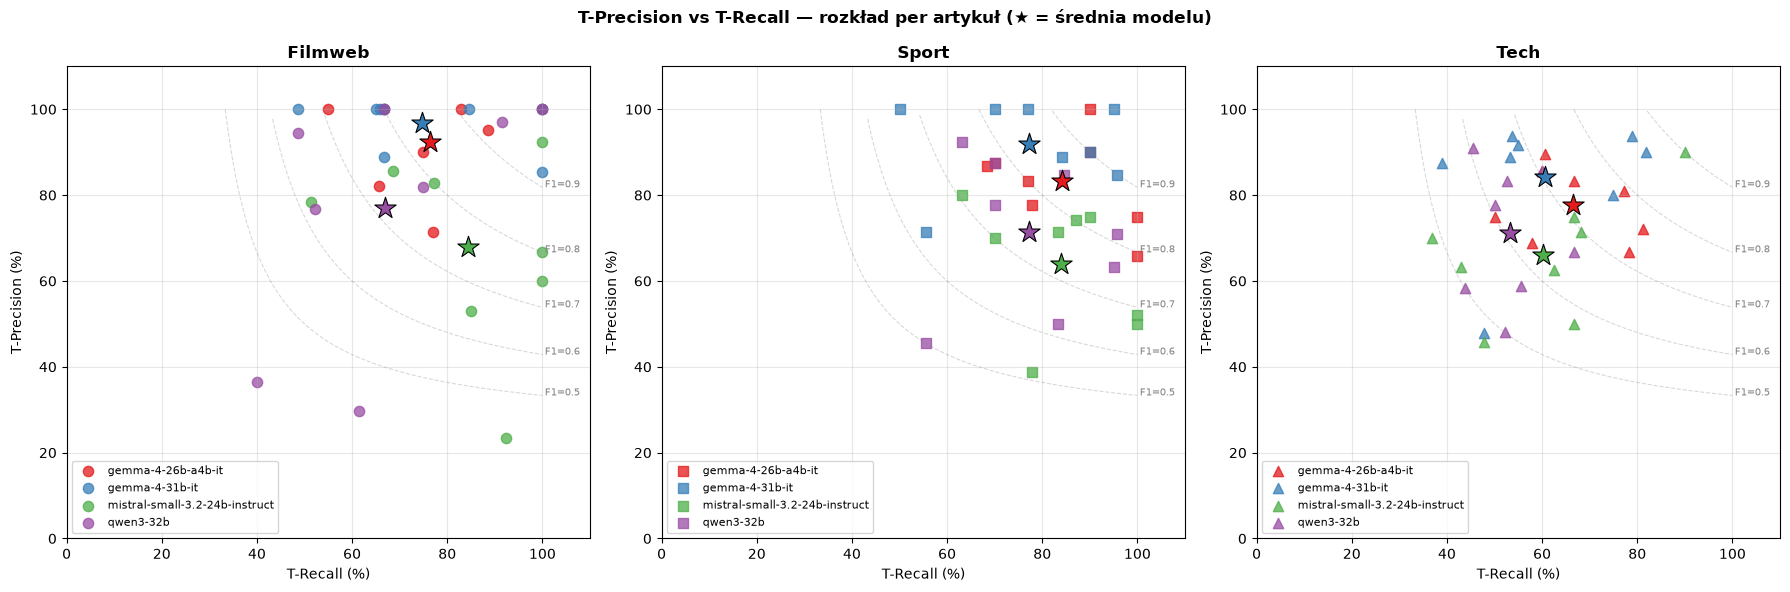

In [8]:
domain_markers = {"Filmweb": "o", "Sport": "s", "Tech": "^"}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, domain in zip(axes, DOMAINS):
    sub = df[df["domain"] == domain]
    for m in TOP4:
        ms = short_label(m)
        rows = sub[sub["model_short"] == ms]
        ax.scatter(rows["t_recall"] * 100, rows["t_precision"] * 100,
                   c=MODEL_COLORS[m], marker=domain_markers[domain],
                   s=55, label=ms, alpha=0.75)
        ax.scatter(rows["t_recall"].mean() * 100, rows["t_precision"].mean() * 100,
                   c=MODEL_COLORS[m], marker="*", s=260,
                   edgecolors="black", linewidths=0.8, zorder=5)

    for f1 in [0.5, 0.6, 0.7, 0.8, 0.9]:
        r = np.linspace(0.01, 1, 200)
        p = f1 * r / (2 * r - f1)
        mask = (p > 0) & (p <= 1)
        ax.plot(r[mask] * 100, p[mask] * 100, "--", color="gray", alpha=0.3, linewidth=0.8)
        ax.text(r[mask][-1] * 100 + 0.5, p[mask][-1] * 100, f"F1={f1:.1f}", fontsize=7, color="gray")

    ax.set_xlim(0, 110); ax.set_ylim(0, 110)
    ax.set_xlabel("T-Recall (%)"); ax.set_ylabel("T-Precision (%)")
    ax.set_title(f"{domain}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("T-Precision vs T-Recall — rozkład per artykuł (★ = średnia modelu)", fontweight="bold")
fig.tight_layout()
plt.show()

## T-F1 per artykuł — każda domena osobno

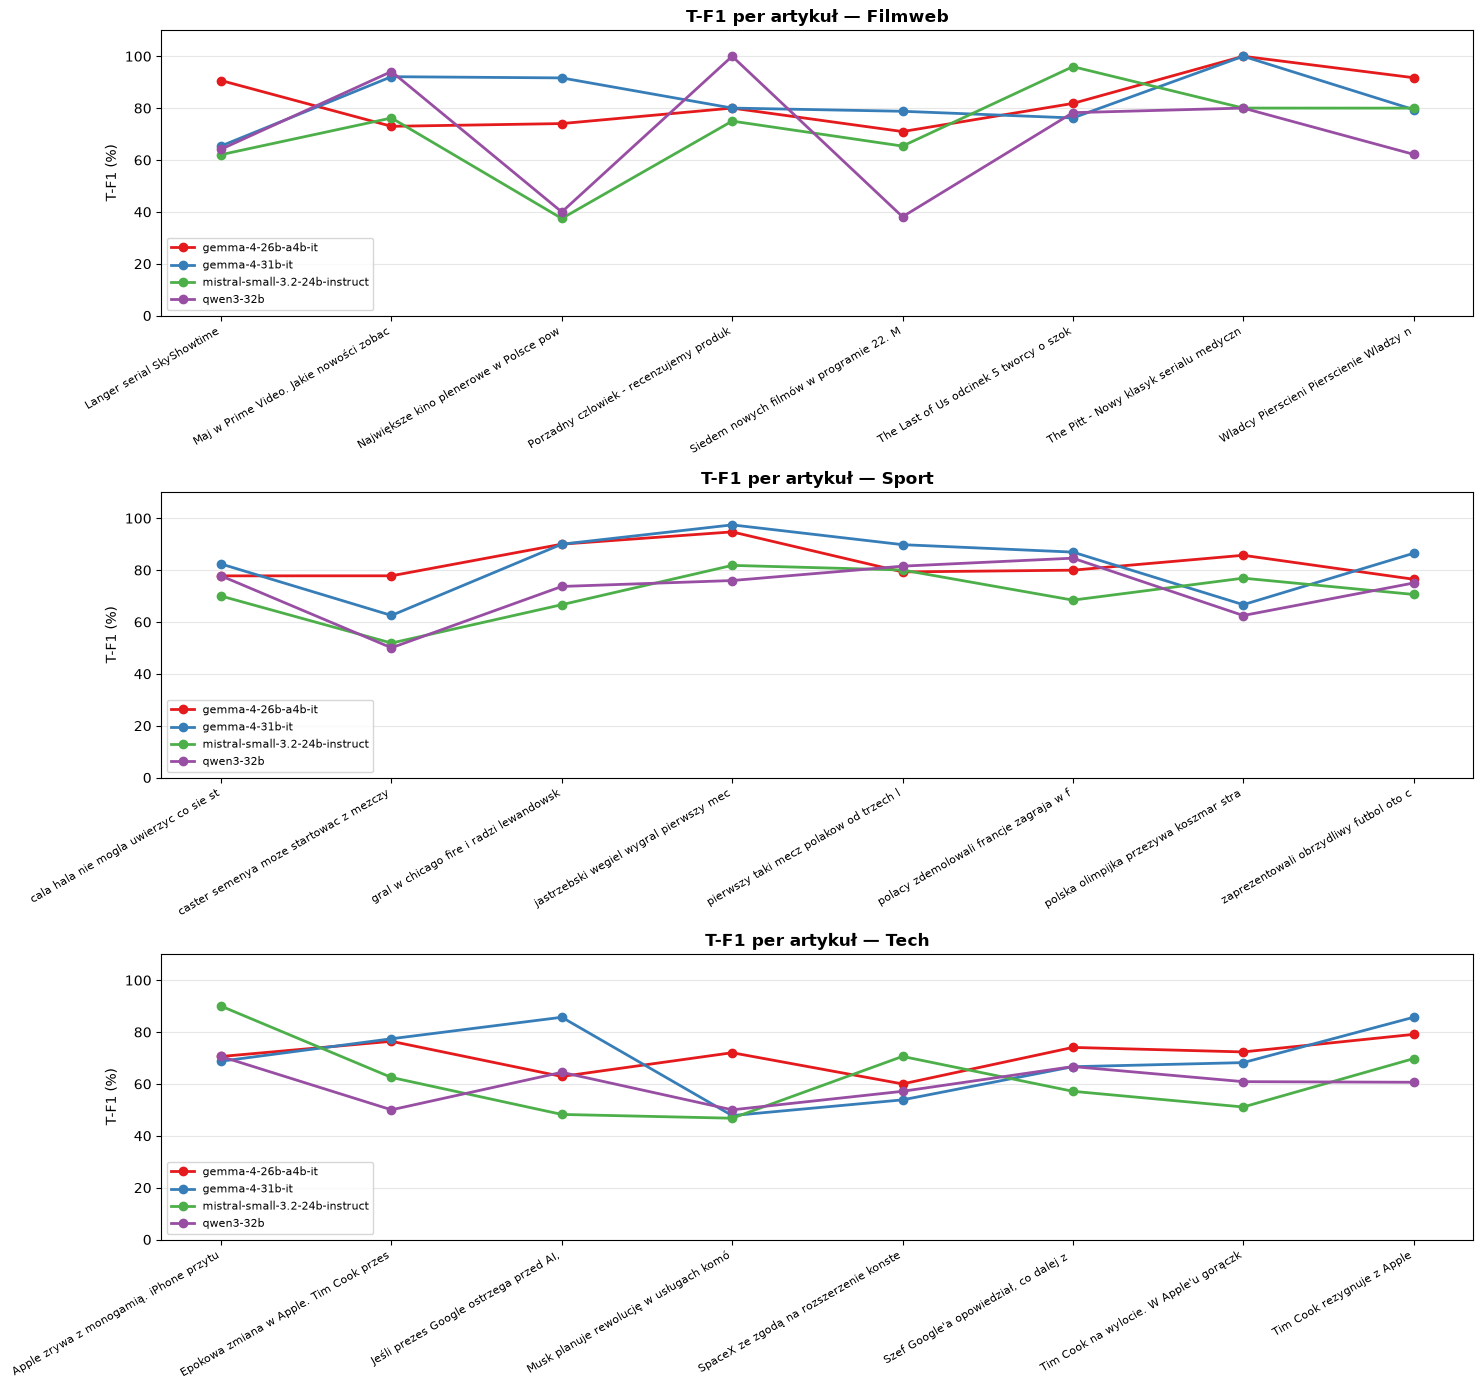

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14))

for ax, domain in zip(axes, DOMAINS):
    sub = df[df["domain"] == domain]
    article_order = sorted(sub["title_short"].unique())
    for m in TOP4:
        ms = short_label(m)
        s = sub[sub["model_short"] == ms].set_index("title_short")
        vals = [s.loc[a, "t_f1"] * 100 if a in s.index else np.nan for a in article_order]
        ax.plot(range(len(article_order)), vals, marker="o",
                label=ms, color=MODEL_COLORS[m], linewidth=2)
    ax.set_xticks(range(len(article_order)))
    ax.set_xticklabels([a[:40] for a in article_order], rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 110)
    ax.set_ylabel("T-F1 (%)")
    ax.set_title(f"T-F1 per artykuł — {domain}", fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## Spójność modeli między domenami (odchylenie standardowe T-F1)

,T-F1 Filmweb,T-F1 Sport,T-F1 Tech,Avg T-F1,StdDev,CV (%)
Model,,,,,,
gemma-4-26b-a4b-it,82.8%,82.7%,70.9%,78.8%,0.068,8.7%
gemma-4-31b-it,83.0%,82.8%,69.3%,78.3%,0.079,10.0%
mistral-small-3.2-24b-instruct,71.5%,70.8%,62.0%,68.1%,0.053,7.8%
qwen3-32b,69.6%,72.6%,60.1%,67.4%,0.066,9.7%


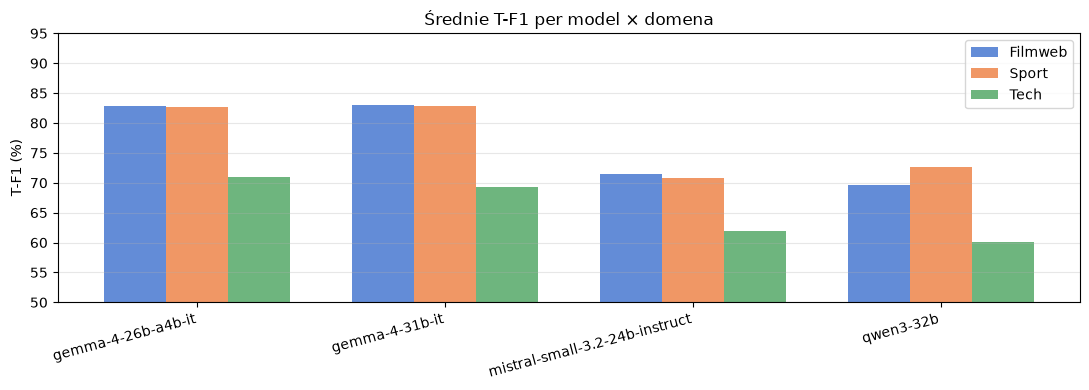

In [10]:
consistency = df.groupby(["model_short", "domain"])["t_f1"].mean().unstack("domain")
consistency.columns = [f"T-F1 {d}" for d in consistency.columns]
consistency["Avg T-F1"] = consistency.mean(axis=1)
consistency["StdDev"] = consistency[[f"T-F1 {d}" for d in DOMAINS]].std(axis=1)
consistency["CV (%)"] = (consistency["StdDev"] / consistency["Avg T-F1"] * 100).round(1)
consistency = consistency.sort_values("Avg T-F1", ascending=False).round(3)
consistency.index.name = "Model"

display(HTML("<h4>Stabilność T-F1 między domenami (niższe StdDev = bardziej spójny model)</h4>"))
display(
    consistency.style
    .background_gradient(subset=[f"T-F1 {d}" for d in DOMAINS], cmap="RdYlGn", vmin=0.5, vmax=0.9)
    .background_gradient(subset=["StdDev", "CV (%)"], cmap="RdYlGn_r", vmin=0, vmax=0.15)
    .format({**{f"T-F1 {d}": "{:.1%}" for d in DOMAINS}, "Avg T-F1": "{:.1%}", "StdDev": "{:.3f}", "CV (%)": "{:.1f}%"})
)

# Bar chart: avg T-F1 per domain per model
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(TOP4))
model_labels = [short_label(m) for m in TOP4]
w = 0.25
for i, domain in enumerate(DOMAINS):
    vals = [consistency.loc[short_label(m), f"T-F1 {domain}"] * 100 for m in TOP4]
    ax.bar(x + (i - 1) * w, vals, w, label=domain, color=DOMAIN_COLORS[domain], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha="right")
ax.set_ylim(50, 95)
ax.set_ylabel("T-F1 (%)")
ax.set_title("Średnie T-F1 per model × domena")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Rankingi per domena

rank_cols = ["precision", "t_precision", "t_recall", "t_f1"]
for domain in DOMAINS:
    display(HTML(f"<h4>Ranking — {domain} (wg T-F1)</h4>"))
    sub = df[df["domain"] == domain]
    r = sub.groupby("model_short")[rank_cols].mean().sort_values("t_f1", ascending=False).round(3)
    r["rank"] = range(1, len(r)+1)
    display(
        r.style
        .background_gradient(subset=rank_cols, cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in rank_cols})
    )

## Analiza Top-2 modeli: Gemma-4-26B i Gemma-4-31B

Poniższa sekcja izoluje dwa najlepsze modele, aby pokazać osiągany poziom jakości bez wpływu słabszych modeli na średnie.

In [11]:
GEMMA = ["gemma-4-26b-a4b-it", "gemma-4-31b-it"]
GEMMA_COLORS = {"gemma-4-26b-a4b-it": "#e41a1c", "gemma-4-31b-it": "#377eb8"}
df_gemma = df[df["model_short"].isin(GEMMA)]

# ── Tabela średnich per model × domena ──────────────────────────────────────
display(HTML("<h4>Średnie metryk — Top-2 modele (Gemma)</h4>"))
gem_agg = (
    df_gemma.groupby(["model_short", "domain"])[NUMERIC].mean()
    .round(3).reset_index()
)
gem_agg["domain"] = pd.Categorical(gem_agg["domain"], categories=DOMAINS, ordered=True)
gem_agg = gem_agg.sort_values(["model_short", "domain"])
gem_agg = gem_agg.rename(columns={"model_short": "Model", "domain": "Domena"})
display(
    gem_agg.style
    .apply(color_domain, axis=1)
    .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0.5, vmax=1)
    .format({c: "{:.1%}" for c in NUMERIC})
    .hide(axis="index")
    .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
)

# ── Tabela: gemma vs. wszystkie modele ───────────────────────────────────────
display(HTML("<h4>Gemma vs. wszystkie modele — porównanie średnich T-F1</h4>"))
compare = pd.DataFrame(index=DOMAINS)
compare["T-F1 (wszystkie)"] = df.groupby("domain")["t_f1"].mean()
compare["T-F1 (gemma)"]     = df_gemma.groupby("domain")["t_f1"].mean()
compare["Δ (gemma − all)"]  = compare["T-F1 (gemma)"] - compare["T-F1 (wszystkie)"]
compare = compare.loc[DOMAINS].round(3)
display(
    compare.style
    .background_gradient(subset=["T-F1 (wszystkie)", "T-F1 (gemma)"], cmap="RdYlGn", vmin=0.5, vmax=0.9)
    .background_gradient(subset=["Δ (gemma − all)"], cmap="RdYlGn", vmin=0, vmax=0.15)
    .format("{:.1%}")
)

Model,Domena,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
gemma-4-26b-a4b-it,Filmweb,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-26b-a4b-it,Sport,77.9%,64.8%,70.4%,83.2%,84.1%,82.7%,87.6%
gemma-4-26b-a4b-it,Tech,91.6%,67.3%,77.4%,77.8%,66.5%,70.9%,84.7%
gemma-4-31b-it,Filmweb,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-31b-it,Sport,89.4%,65.0%,74.2%,91.9%,77.2%,82.8%,89.3%
gemma-4-31b-it,Tech,93.6%,65.6%,76.5%,84.2%,60.5%,69.3%,93.2%


,T-F1 (wszystkie),T-F1 (gemma),Δ (gemma − all)
Filmweb,76.7%,82.9%,6.2%
Sport,77.2%,82.7%,5.5%
Tech,65.6%,70.1%,4.5%


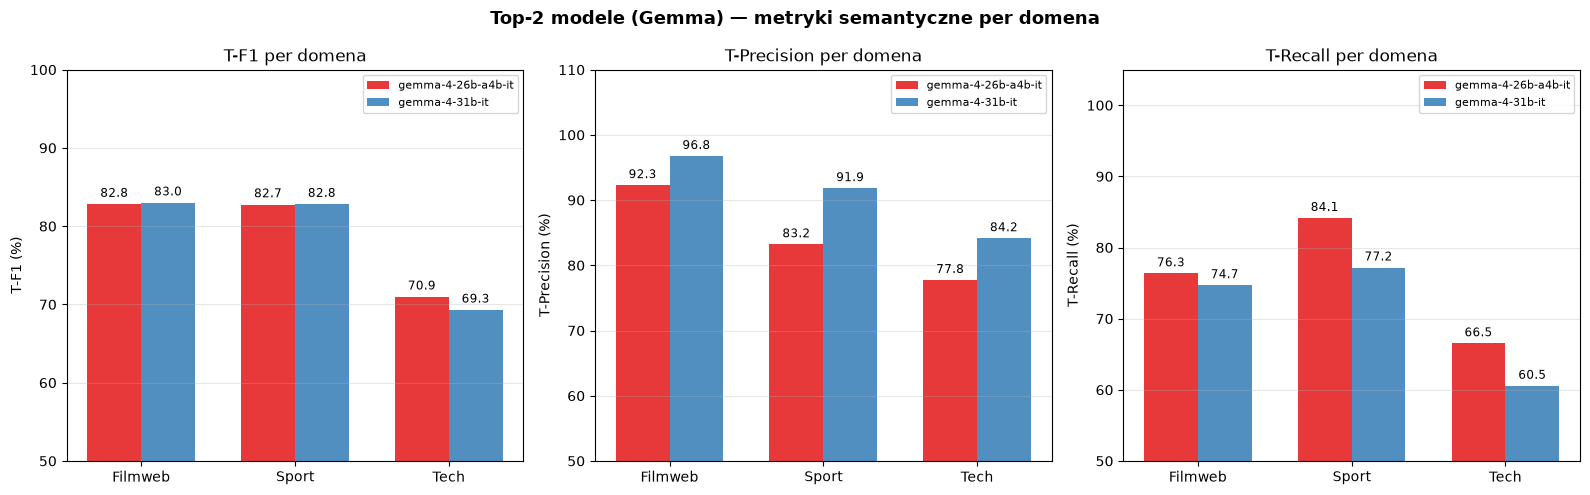

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── wykres 1: T-F1 per domena, gemma side-by-side ───────────────────────────
ax = axes[0]
gem_pivot = df_gemma.groupby(["model_short", "domain"])["t_f1"].mean().unstack("domain")
x = np.arange(len(DOMAINS)); w = 0.35
for i, m in enumerate(GEMMA):
    vals = [gem_pivot.loc[m, d] * 100 for d in DOMAINS]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=m, color=GEMMA_COLORS[m], alpha=0.87)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(DOMAINS)
ax.set_ylim(50, 100); ax.set_ylabel("T-F1 (%)"); ax.set_title("T-F1 per domena")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# ── wykres 2: T-Precision per domena ────────────────────────────────────────
ax = axes[1]
gem_tp = df_gemma.groupby(["model_short", "domain"])["t_precision"].mean().unstack("domain")
for i, m in enumerate(GEMMA):
    vals = [gem_tp.loc[m, d] * 100 for d in DOMAINS]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=m, color=GEMMA_COLORS[m], alpha=0.87)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(DOMAINS)
ax.set_ylim(50, 110); ax.set_ylabel("T-Precision (%)"); ax.set_title("T-Precision per domena")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# ── wykres 3: T-Recall per domena ───────────────────────────────────────────
ax = axes[2]
gem_tr = df_gemma.groupby(["model_short", "domain"])["t_recall"].mean().unstack("domain")
for i, m in enumerate(GEMMA):
    vals = [gem_tr.loc[m, d] * 100 for d in DOMAINS]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=m, color=GEMMA_COLORS[m], alpha=0.87)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(DOMAINS)
ax.set_ylim(50, 105); ax.set_ylabel("T-Recall (%)"); ax.set_title("T-Recall per domena")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

fig.suptitle("Top-2 modele (Gemma) — metryki semantyczne per domena", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [13]:
# Heatmapa T-F1 tylko dla Gemm — model × artykuł × domena
for domain in DOMAINS:
    display(HTML(f"<h4>T-F1 (Gemma) — {domain}</h4>"))
    sub = df_gemma[df_gemma["domain"] == domain]
    pivot = sub.pivot_table(index="model_short", columns="title_short", values="t_f1")
    pivot["Średnia"] = pivot.mean(axis=1)
    display(
        pivot.style
        .background_gradient(cmap="RdYlGn", vmin=0.4, vmax=1)
        .format("{:.1%}")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap"), ("font-size", "9.5px")]}])
    )

title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobac,Największe kino plenerowe w Polsce pow,Porzadny czlowiek - recenzujemy produk,Siedem nowych filmów w programie 22. M,The Last of Us odcinek 5 tworcy o szok,The Pitt - Nowy klasyk serialu medyczn,Wladcy Pierscieni Pierscienie Wladzy n,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,90.7%,73.0%,74.0%,80.0%,71.0%,81.8%,100.0%,91.7%,82.8%
gemma-4-31b-it,65.4%,92.1%,91.7%,80.0%,78.8%,76.2%,100.0%,79.4%,83.0%


title_short,cala hala nie mogla uwierzyc co sie st,caster semenya moze startowac z mezczy,gral w chicago fire i radzi lewandowsk,jastrzebski wegiel wygral pierwszy mec,pierwszy taki mecz polakow od trzech l,polacy zdemolowali francje zagraja w f,polska olimpijka przezywa koszmar stra,zaprezentowali obrzydliwy futbol oto c,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,77.8%,77.8%,90.0%,94.7%,79.3%,80.0%,85.7%,76.5%,82.7%
gemma-4-31b-it,82.4%,62.5%,90.0%,97.4%,89.8%,86.9%,66.7%,86.5%,82.8%


title_short,Apple zrywa z monogamią. iPhone przytu,Epokowa zmiana w Apple. Tim Cook przes,"Jeśli prezes Google ostrzega przed AI,",Musk planuje rewolucję w usługach komó,SpaceX ze zgodą na rozszerzenie konste,"Szef Google'a opowiedział, co dalej z",Tim Cook na wylocie. W Apple'u gorączk,Tim Cook rezygnuje z Apple,Średnia
model_short,,,,,,,,,
gemma-4-26b-a4b-it,70.6%,76.4%,62.9%,72.0%,60.0%,74.1%,72.3%,79.1%,70.9%
gemma-4-31b-it,68.8%,77.4%,85.7%,47.8%,53.9%,66.6%,68.2%,85.7%,69.3%


## Wnioski: uniwersalność rozwiązania — analiza 3 domen

### Zestawienie T-F1 per model × domena

| Model | Filmweb | Sport | Tech | ΔSport | ΔTech |
|---|---|---|---|---|---|
| gemma-4-26b-a4b-it | 82.8% | 82.7% | ~70.9% | −0.1 pp | **−11.9 pp** |
| gemma-4-31b-it | 83.0% | 82.8% | ~69.3% | −0.2 pp | **−13.7 pp** |
| mistral-small-3.2-24b-instruct | 71.5% | 70.8% | ~62.0% | −0.7 pp | **−9.5 pp** |
| qwen3-32b | 69.6% | 72.6% | ~60.1% | +3.0 pp | **−9.5 pp** |

---

### 1. Filmweb ↔ Sport: pełna generalizacja semantyczna

T-F1 między filmweb i sportem różni się o mniej niż 1 pp dla wszystkich modeli — to szum statystyczny przy n=8. Ranking modeli jest zachowany. Wniosek z poprzedniej analizy pozostaje aktualny: modele generalizują semantycznie między tymi domenami bez żadnych zmian.

---

### 2. Technologia: wyraźny spadek T-F1 (~10–14 pp)

W przeciwieństwie do sportu, domena technologiczna powoduje **mierzalny spadek T-F1** u wszystkich modeli. Szczególnie widoczne jest to w **T-Recall** — modele pokrywają mniej relacji z grafu referencyjnego niż w innych domenach. T-Precision jest stosunkowo wysoka (modele ekstrapolują mało, ale i nie wydobywają wystarczająco dużo).

**Dlaczego technologia jest trudniejsza semantycznie?**

- Artykuły technologiczne dotyczące sukcesji w Apple i planów SpaceX/Starlink zawierają wiele **relacji hierarchicznych i planistycznych**: kto zastąpi kogo, kto jest podwładnym kogo, jakie są długofalowe strategie. Modele ekstrapolują je oszczędniej niż Claude Opus.
- Tematy takie jak ograniczenia FCC, pozwolenia na ekspansję konstelacji Starlink czy ostrzeżenia przed AI mają **wysoki udział ocen i predykcji** (np. *"Sundar Pichai ostrzega przed AI"*) — graniczne przypadki ekstrakcji, gdzie modele i sędzia różnią się w ocenie.
- Prompt `technology` był tworzony bez iteracji podobnie jak `sport_pl`, ale sport ma prostą strukturę encji (zawodnik → wynik → drużyna), podczas gdy technologia ma złożone sieci korporacyjne.

---

### 3. Ranking modeli jest zachowany we wszystkich 3 domenach

Niezależnie od domeny: **gemma-4-26b ≈ gemma-4-31b > mistral > qwen3-32b** (wg T-F1). To ważne stwierdzenie: wybór najlepszego modelu dla jednej domeny jest reprezentatywny dla pozostałych.

---

### 4. Wniosek o uniwersalności — zaktualizowany

**Rozwiązanie generalizuje częściowo, z domenowo zależną trudnością:**

- **Sport**: pełna generalizacja semantyczna — T-F1 stabilny (±1 pp vs filmweb). Precision niższa ze względu na jakość promptu, nie modelu.
- **Technologia**: umiarkowana generalizacja — T-F1 spada o 10–14 pp. Przyczyna leży głównie w specyfice domeny (złożone relacje hierarchiczne, predykcje, plany), a nie wyłącznie w jakości promptu.

Oznacza to że **bottleneck ma dwie składowe**: jakość promptu domenowego (wpływa na precision) oraz inherentna trudność domeny pod kątem spójnego definiowania granic ekstrakcji (wpływa na T-Recall). Pierwsza jest eliminowalna przez lepszy prompt engineering; druga jest ograniczeniem fundamentalnym — pewne domeny są obiektywnie trudniejsze dla ekstrakcji grafów wiedzy niż inne.